In [2]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import warnings
# warnings.filterwarnings("ignore")

data_dir = '/home/edavenport/analysis/TPOSE6_VelocityAssim/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 5 #
itPerFile = 720 # 1 day
intervals = range(0,itPerFile*num_diags,itPerFile) # adjoint sensitivity will start at 0 and go to 1 lag (1 interval less than total number of timesteps)

# when prefix is not set, this will read all available files 
# have to ignore unkown vars until we have an available_diagnostics.log that includes ADJrhoinsitu
tpose_ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,ref_date='2012-09-01',delta_t=1200,ignore_unknown_vars=True)
tpose_ds['XC'] = tpose_ds.XC.astype(float)
tpose_ds['YC'] = tpose_ds.YC.astype(float)
tpose_ds['Z'] = tpose_ds.Z.astype(float)
tpose_ds['XG'] = tpose_ds.XG.astype(float)
tpose_ds['YG'] = tpose_ds.YG.astype(float)

In [3]:
tpose_ds.ADJuvel

<xarray.DataArray 'ADJuvel' (time: 5, Z: 66, YC: 336, XG: 1128)> Size: 500MB
dask.array<concatenate, shape=(5, 66, 336, 1128), dtype=float32, chunksize=(1, 66, 336, 1128), chunktype=numpy.ndarray>
Coordinates: (12/13)
    iter     (time) int64 40B dask.array<chunksize=(1,), meta=np.ndarray>
  * time     (time) datetime64[ns] 40B 2012-09-01 2012-09-11 ... 2012-10-11
  * YC       (YC) float64 3kB -25.92 -25.75 -25.58 -25.42 ... 29.58 29.75 29.92
  * XG       (XG) float64 9kB 104.0 104.2 104.3 104.5 ... 291.5 291.7 291.8
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
    dyG      (YC, XG) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    ...       ...
    rAw      (YC, XG) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    drF      (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    PHrefC   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    hFacW    (Z, YC, XG) >f4 100MB dask.array<chunksize=(66, 336, 1128), meta=np.ndarray>
    maskW    (Z, YC, XG) bool 25MB dask.array<chunksize=(66, 336, 1128), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
Attributes:
    standard_name:  ADJuvel
    long_name:      dJ/dU: Sensitivity to zonal velocity
    units:          dJ/(m/s)
    mate:           ADJvvel

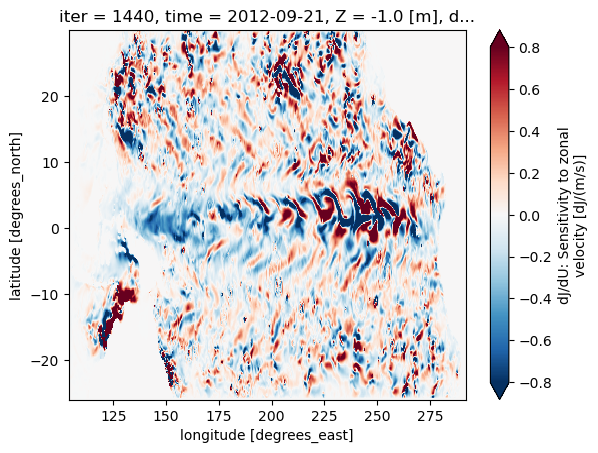

In [8]:
tpose_ds.ADJuvel.isel(time=2,Z=0).plot(robust=True)